# Problem - Identify Duplicates

Given an integer array nums of length n where all the integers of nums are in the range `[1, n]` and each integer appears once or twice, return an array of all the integers that appears twice. You must write an algorithm that runs in O(n) time and uses only constant extra space.

**Input**: `nums = [4,3,2,7,8,2,3,1]`

**Output**: `[2,3]`

# 🧠 Pattern: Index Marking / Sign-Marking Technique

This belongs to the **Index Manipulation Pattern** where:
* Array values lie within a restricted range → `[1..n]`
* We can use the **array indices** themselves to track occurrences.

This pattern is commonly used in:
* Finding duplicates
* Finding missing numbers
* Cyclic sort pattern
* Detecting repeated / misplaced numbers
* In-place hashing

# 🎯 Intuition

Since all values are between **1 and n**, each number maps to a unique index: **`number x  →  index (x - 1)`**

```
number x  →  index (x - 1)
```

**Key Insight:**

When a number x appears for the **first time**:
* We go to index `x - 1`
* We **flip the sign** of that value → mark **“visited”**

When x appears again:
* We again go to index **`x - 1`**
* But the value is already **negative**
* This means → **duplicate detected**

So:
* **1st visit → mark by making value negative**
* **2nd visit → index already negative → duplicate**

No extra space needed — the array itself stores visitation info.

# 🔧 Technique (Step-by-Step)

Let’s walk through the example: `nums = [4,3,2,7,8,2,3,1]`

Initialize result array: `result = []`

**Traverse each number:**

For each value num:
1. Convert it to an index: `idx = abs(num) - 1`
2. If `nums[idx]` is **positive → first time**, mark it negative
3. If `nums[idx]` is **negative → second time**, add the number to result


# 🧮 Dry Run

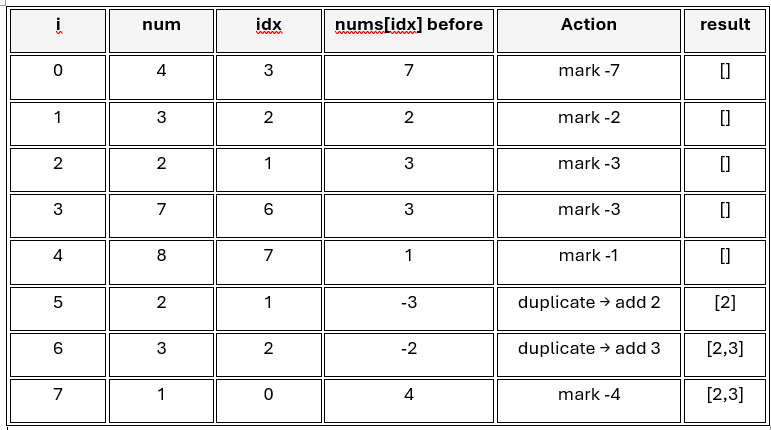

**Output**: `[2,3]`

# 🧩 Why This Works

* Each number `(1 to n)` maps to a **unique index**.
* Making that index **negative** marks visitation.
* Using the array allows us to simulate a **hash map** with `O(1)` extra space.
* Detecting negative means **we have seen this number before**.
* No need for sorting or extra memory.

This satisfies:
* ✔ O(n) time
* ✔ O(1) space
* ✔ No hash set
* ✔ No extra arrays

# Solution

In [1]:
def findDuplicates(nums):
    result = []

    for num in nums:
        idx = abs(num) - 1

        # If already negative → seen before → duplicate found
        if nums[idx] < 0:
            result.append(abs(num))
        else:
            nums[idx] = -nums[idx]  # mark as visited

    return result

nums = [4,3,2,7,8,2,3,1]
print(findDuplicates(nums))

[2, 3]


**Time Complexity**: `O(n)`

**Space Complexity**: `O(1)`


# 🧠 When to Use This Pattern

Use **index-sign marking** when:
* Values are limited to **`[1 .. n]`**
* You must achieve **`O(1)`** extra space
* You need to find:
    * duplicates
    * missing numbers
    * first repeated number
    * numbers appearing k times (modified)

This pattern is heavily used in FAANG interviews.

# 🚀 Summary (One-Liner)

Treat the array like a hash map.

For each value **`x`**, go to index **`x-1`**:
* If positive → **mark negative** (first seen)
* If already negative → **duplicate found** (add to result list).